In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cpu


Latent Vector Shape: torch.Size([1, 100])


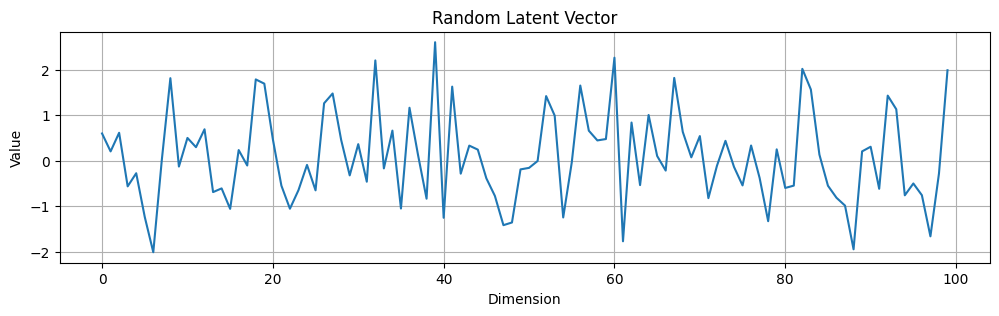

In [2]:
latent_vector = torch.randn(1, 100)

print("Latent Vector Shape:", latent_vector.shape)

plt.figure(figsize=(12,3))
plt.plot(latent_vector.numpy().flatten())
plt.title("Random Latent Vector")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [3]:
age = 60

age_vector = torch.tensor([age/100.0])

print("Target Age:", age)
print("Normalized Age Vector:", age_vector)

Target Age: 60
Normalized Age Vector: tensor([0.6000])


In [4]:
identity_vector = torch.randn(1,100)

combined = torch.cat((identity_vector, age_vector.unsqueeze(0)),dim=1)

print("Identity Shape :",identity_vector.shape)
print("Combined Shape :",combined.shape)

Identity Shape : torch.Size([1, 100])
Combined Shape : torch.Size([1, 101])


In [5]:
class MiniGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(101,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,784),
            nn.Tanh()

        )

    def forward(self,x):

        return self.network(x)

generator = MiniGenerator()

print(generator)

MiniGenerator(
  (network): Sequential(
    (0): Linear(in_features=101, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)


In [6]:
fake_face = generator(combined)

print(fake_face.shape)

torch.Size([1, 784])


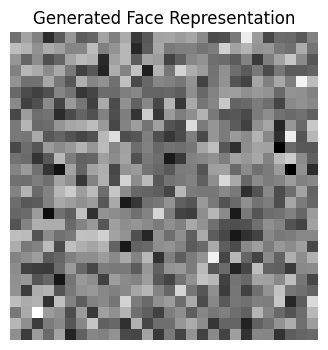

In [7]:
image = fake_face.detach().numpy().reshape(28,28)

plt.figure(figsize=(4,4))
plt.imshow(image,cmap="gray")
plt.title("Generated Face Representation")
plt.axis("off")
plt.show()

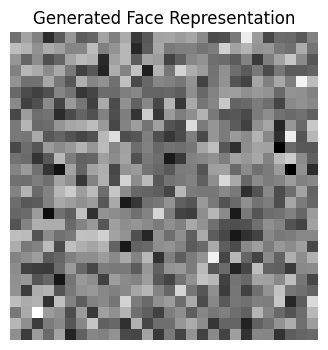

In [8]:
image = fake_face.detach().numpy().reshape(28,28)

plt.figure(figsize=(4,4))
plt.imshow(image,cmap="gray")
plt.title("Generated Face Representation")
plt.axis("off")
plt.show()

In [9]:
prediction = discriminator(fake_face)

print("Real/Fake Probability:",prediction.item())

NameError: name 'discriminator' is not defined

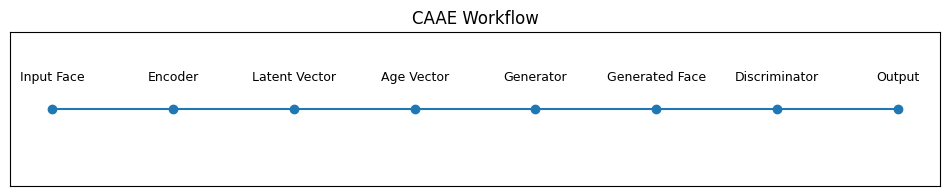

In [10]:
workflow = [
    "Input Face",
    "Encoder",
    "Latent Vector",
    "Age Vector",
    "Generator",
    "Generated Face",
    "Discriminator",
    "Output"
]

plt.figure(figsize=(12,2))

plt.plot(range(len(workflow)),np.ones(len(workflow)),"o-")

for i,text in enumerate(workflow):
    plt.text(i,1.02,text,ha='center',fontsize=9)

plt.yticks([])
plt.xticks([])
plt.title("CAAE Workflow")

plt.show()

In [11]:
total_params = sum(p.numel() for p in generator.parameters())

print("Generator Parameters:",total_params)

total_disc = sum(p.numel() for p in discriminator.parameters())

print("Discriminator Parameters:",total_disc)

Generator Parameters: 559888


NameError: name 'discriminator' is not defined

# Conclusion

In this notebook, I explored the architecture of Conditional Adversarial Autoencoders (CAAE) and Age-Conditional GANs.

### Key Learnings

- Understood latent space representation.
- Learned how age conditioning is incorporated into the generator.
- Implemented a simplified Generator and Discriminator in PyTorch.
- Performed a forward pass using random latent vectors and age information.
- Explored the workflow of facial age progression models before implementing a complete pretrained solution in the final project.